# Supplementary Figure S44: cross-dataset benchmark summary

Recalculate the 33 matched benchmark comparisons and draw the figure from the included numerical results. This notebook does not read or re-export the published figure.


## Inputs and preceding calculation

The original nine model and interpolation results come from the five completed leave-one-time-point-out benchmark runs described in the [S45 notebook](loto_benchmark.ipynb). The ARISTA and chicken-heart rows use the retrained models used for the revised figure. Linear OT and SpaTrack were evaluated separately on the same held-out inputs and with the same five Sliced-W2 projection repeats.

SpaTrack uses Euclidean distances between the shared PCA features, its spatial transport term, and barycentric interpolation to the held-out time. It is a PCA-based adaptation of the multi-time-point solver. The release directory contains the input tables, repeat-level Linear OT and SpaTrack metrics, the calculation and plotting code, and the run settings.

To recompute SpaTrack, start with the `inputs` folders created in step 1 of the S45 notebook. The [SpaTrack instructions](spatrack_benchmark.md) give the exact input files, fitting and evaluation commands, and how to pass a new run to this figure. The cells below redraw the published comparison from its numerical results.


In [1]:
from pathlib import Path
import os
import subprocess
import sys

import pandas as pd
from IPython.display import Image, display


def find_repository(start: Path) -> Path:
    candidates = [start, *start.parents]
    candidates.extend(
        Path(entry).expanduser().resolve()
        for entry in os.environ.get('PYTHONPATH', '').split(os.pathsep)
        if entry
    )
    for candidate in candidates:
        if (candidate / 'release_artifacts' / 'five_dataset_loto_summary_20260904').is_dir():
            return candidate
    raise FileNotFoundError('Run this notebook from a cytobridge-spatial source checkout.')


repository = find_repository(Path.cwd().resolve())
release = repository / 'release_artifacts' / 'five_dataset_loto_summary_20260904'
output_dir = Path('outputs') / 'loto_benchmark_summary'
table_dir = output_dir / 'tables'
figure_pdf = output_dir / 'five_dataset_loto_summary.pdf'
manifest = output_dir / 'run_manifest.json'
output_dir.mkdir(parents=True, exist_ok=True)
release.relative_to(repository)


PosixPath('release_artifacts/five_dataset_loto_summary_20260904')

## Recalculate and draw

The script reads the target-stage means and the repeat-level Linear OT and SpaTrack results, recalculates the ranking and paired relative-error tables, and writes new PDF and PNG files.


In [2]:
command = [
    sys.executable,
    str(release / 'code' / 'plot_five_dataset_loto_wins_summary.py'),
    '--input', str(release / 'source_data' / 'loto_target_stage_means.csv'),
    '--linear-ot-root', str(release / 'source_data' / 'linear_ot_metrics'),
    '--spatrack-metrics', str(release / 'source_data' / 'spatrack_metrics.csv'),
    '--table-output-dir', str(table_dir),
    '--output', str(figure_pdf),
    '--manifest', str(manifest),
]
_ = subprocess.run(command, check=True)


## Check the recalculated counts


In [3]:
display_names = {
    'CytoBridge-0.015': 'CytoBridge',
    'exact_ot_displacement': 'Linear OT displacement',
    'stvcr': 'stVCR',
    'moscot': 'MOSCOT',
    'paste': 'PASTE',
    'spatrack_pca': 'SpaTrack',
}
counts = pd.read_csv(table_dir / 'loto_win_counts.csv').rename(
    columns={'win_count': 'comparisons_with_lowest_sliced_w2'}
)
counts['method'] = counts['method'].map(display_names).fillna(counts['method'])
counts.loc[counts['comparisons_with_lowest_sliced_w2'].gt(0)].sort_values(
    'comparisons_with_lowest_sliced_w2', ascending=False
).reset_index(drop=True)


,method,comparisons_with_lowest_sliced_w2
0,CytoBridge,12
1,Linear OT displacement,11
2,PASTE,6
3,stVCR,2
4,MOSCOT,2


## Figure


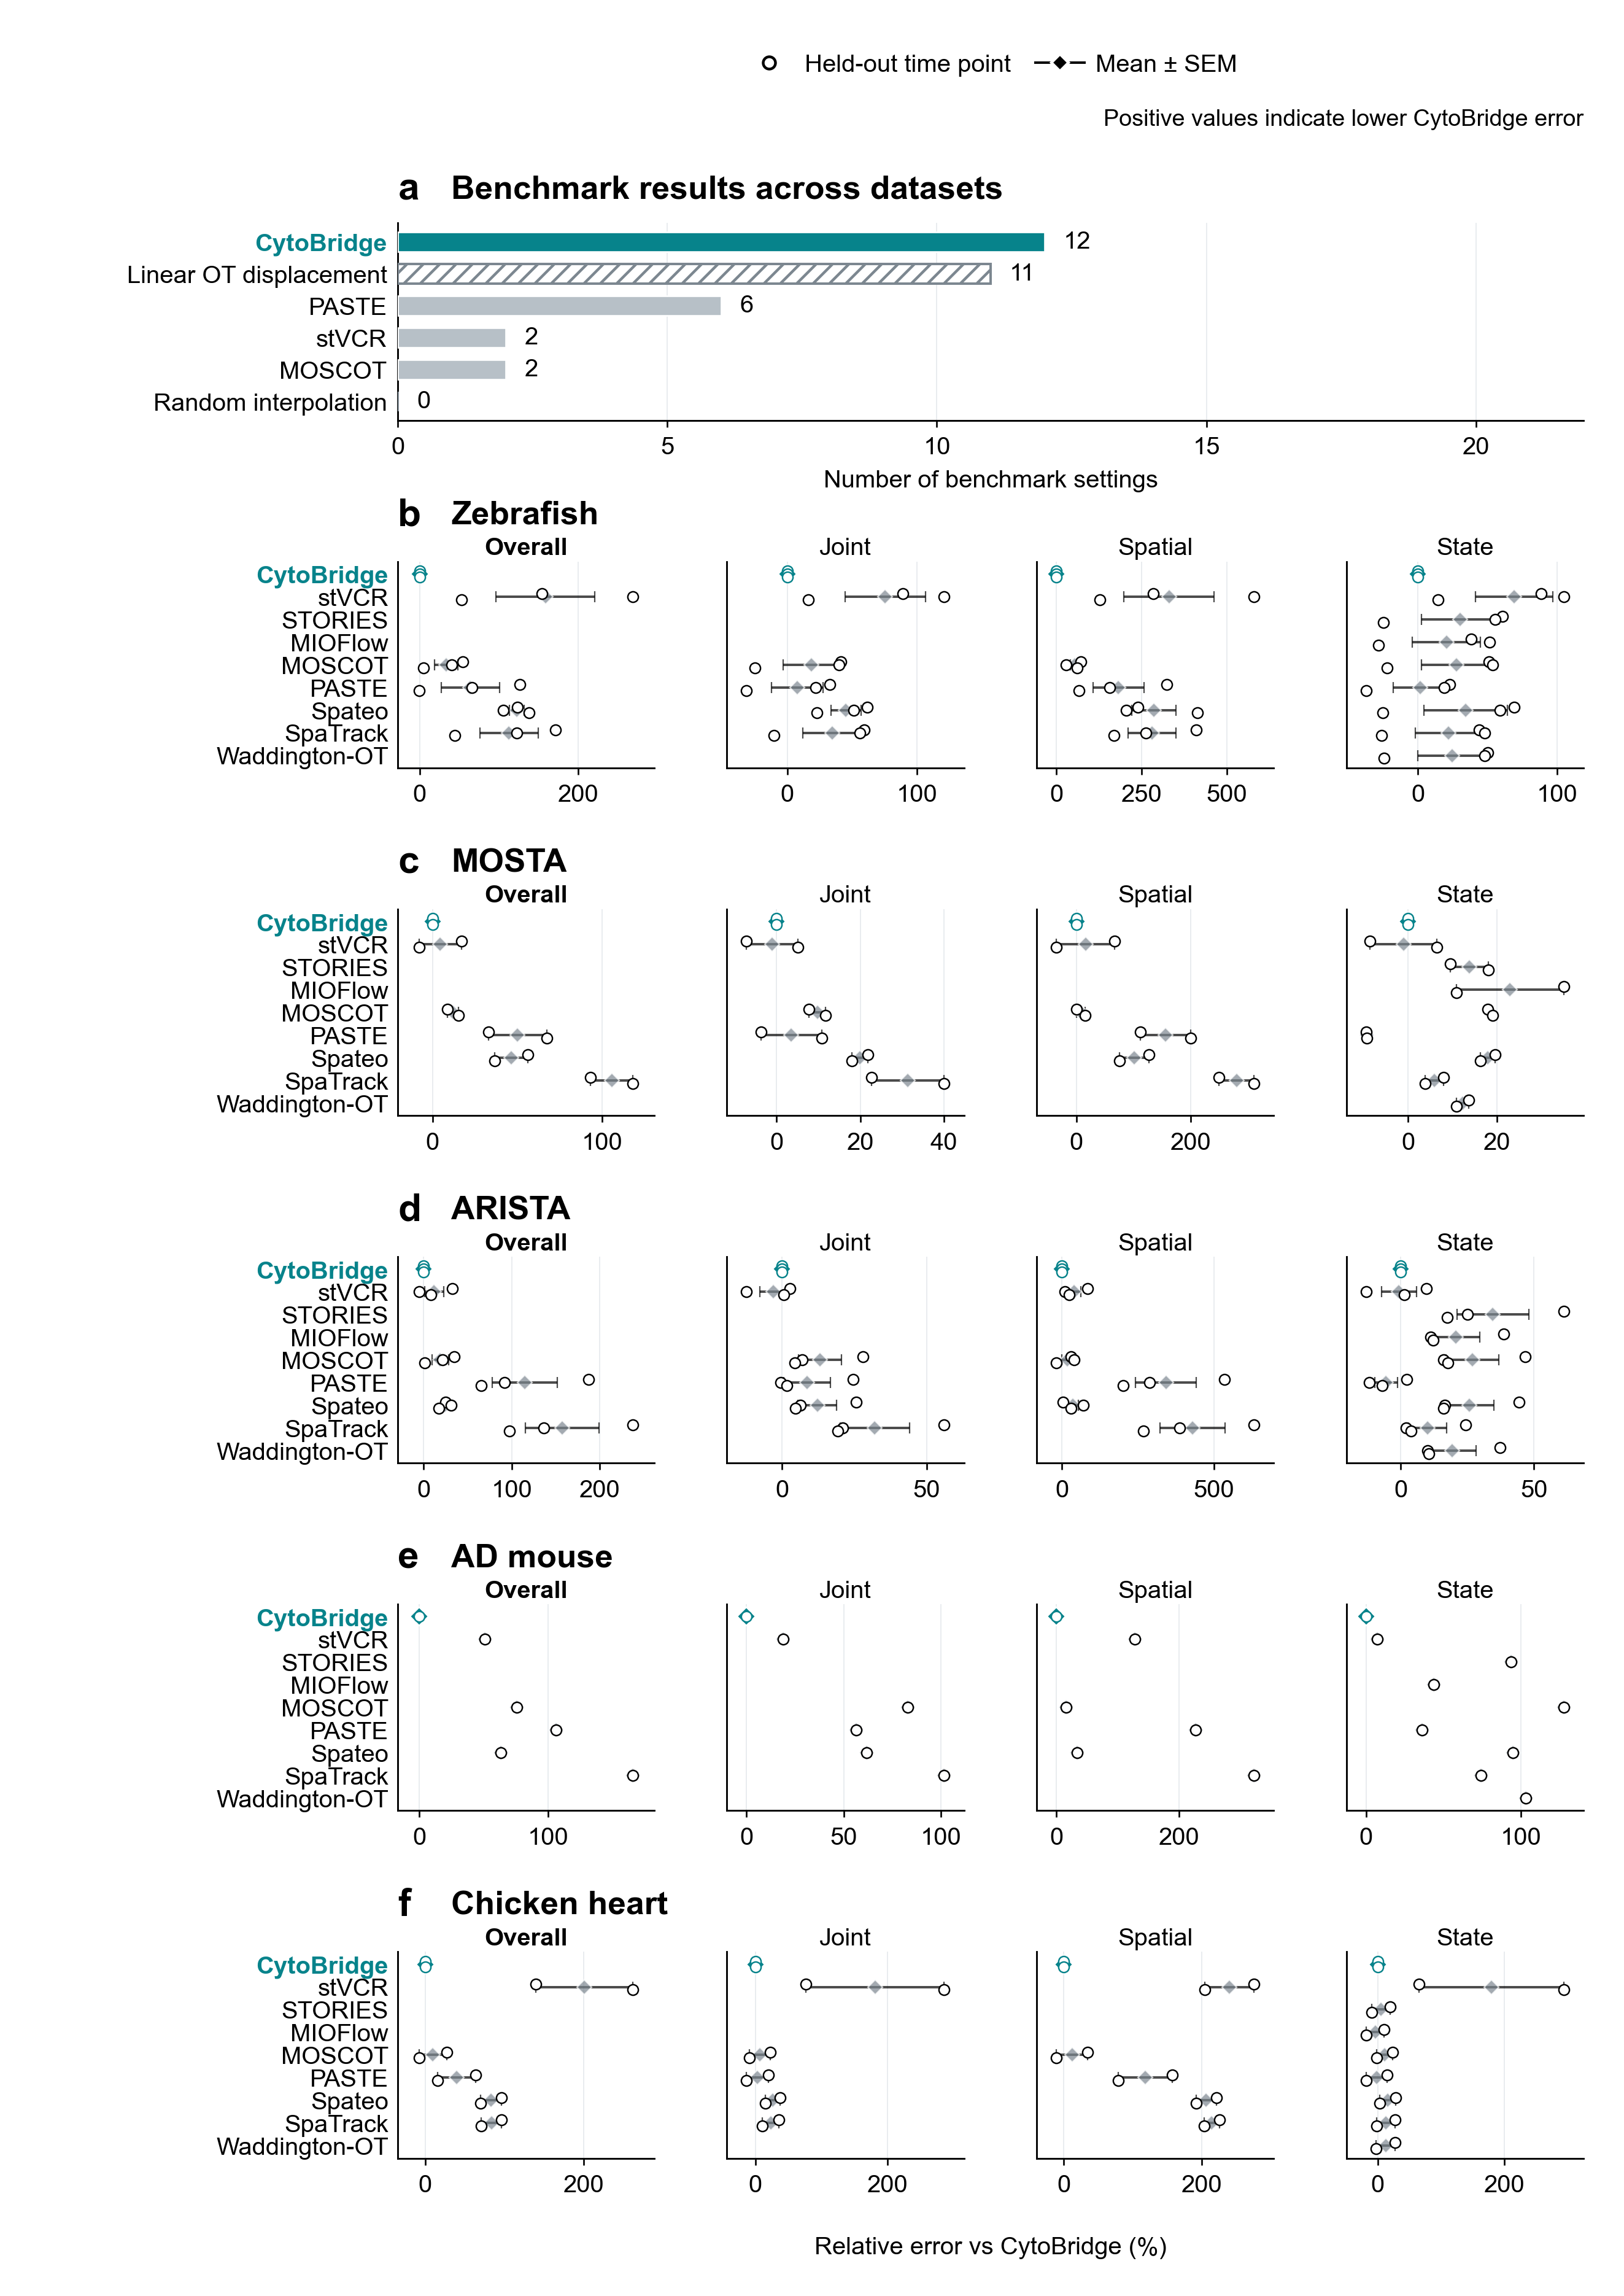

{'pdf': 'outputs/loto_benchmark_summary/five_dataset_loto_summary.pdf',
 'png': 'outputs/loto_benchmark_summary/five_dataset_loto_summary.png',
 'tables': ['loto_model_relative_to_cytobridge.csv',
  'loto_target_stage_means_with_linear_ot.csv',
  'loto_target_stage_means_with_spatrack.csv',
  'loto_target_stage_ranks.csv',
  'loto_win_counts.csv'],
 'manifest': 'outputs/loto_benchmark_summary/run_manifest.json'}

In [4]:
display(Image(filename=str(figure_pdf.with_suffix('.png')), width=760))
{
    'pdf': str(figure_pdf),
    'png': str(figure_pdf.with_suffix('.png')),
    'tables': sorted(path.name for path in table_dir.glob('*.csv')),
    'manifest': str(manifest),
}
